# Fase 1 y 2 — Business Understanding + Data Understanding (EDA)
## Sistema Inteligente de Recomendación de Películas — MovieLens 25M

Notebook `01_Business_Understanding_and_EDA.ipynb` — **CRISP-DM Fase 1 (Business Understanding)** + **CRISP-DM Fase 2 (Data Understanding)**.

Este notebook abre el pipeline del proyecto OmniRec-Movies. Cumple dos fases consecutivas de CRISP-DM en un único flujo narrativo:
1. **Fase 1 — Business Understanding**: formulación del problema de recomendación, criterios de éxito, restricciones técnicas, plan general.
2. **Fase 2 — Data Understanding**: EDA exhaustivo sobre los 25 M de ratings originales con Polars lazy, 14 secciones con *insight de negocio* por bloque, que justifican todas las decisiones de preparación y modelado posteriores.

El siguiente eslabón del pipeline es `02_Data_Sampling_and_Cleaning.ipynb` (Fase 3 — Data Preparation), que toma los hallazgos de este notebook y produce los parquets muestreados.

## 1. Business Understanding — CRISP-DM Fase 1

### 1.1 Contexto y objetivo del proyecto
OmniRec-Movies es un **sistema inteligente de recomendación de películas** entrenado sobre MovieLens 25M (GroupLens, noviembre 2019). El objetivo final es producir, para cada usuario, un ranking personalizado de películas que maximice una de las siguientes métricas:

- **Predicción de rating**: RMSE, MAE (cuán cerca predice el modelo la calificación exacta).
- **Ranking Top-N**: Precision@K, Recall@K, NDCG@K (si las películas relevantes aparecen en las primeras K posiciones).

### 1.2 Criterios de éxito (metodológicos)

| # | Criterio | Cómo se mide |
|---|---|---|
| 1 | **Representatividad estadística** de la muestra. | Distribución de ratings, géneros y tiers de usuario deben ser estadísticamente indistinguibles entre *población* y *muestra* (test χ² / KS informal). |
| 2 | **Factibilidad computacional** en hardware local (2 – 10 CPUs, 8 – 16 GB RAM). | El pipeline completo debe correr en < 15 min sin errores OOM. |
| 3 | **Reproducibilidad total**. | Cualquier ejecución con `SEED=42` produce los mismos parquets, mismos conteos y las mismas estadísticas. |
| 4 | **Trazabilidad de decisiones**. | Cada filtro (muestreo, cold-start, columnas) queda explícitamente justificado con una celda markdown antes del código que lo ejecuta. |

### 1.3 Restricciones y premisas

- **Tamaño**: `ratings.csv` pesa 647 MB (25 M filas). Un `pd.read_csv` completo consume ~2.5 GB de RAM → viable pero al límite.
- **Sparsity**: la matriz usuario×película tiene 99.74 % de celdas vacías (verificado en la fase EDA). Esto **obliga** a usar modelos latentes (SVD/ALS/NMF/NCF) más adelante.
- **Long tail de películas**: > 40 % del catálogo tiene menos de 20 votos → ruido que degrada cualquier algoritmo de CF.
- **Power users**: la distribución de `ratings/usuario` sigue una ley de potencias; un muestreo aleatorio simple sobre-representaría a los heavy users.

### 1.4 Plan de preparación (resumen)

1. **Muestreo estratificado por tier de actividad** al 5 % → conserva la forma de la distribución por tipo de usuario.
2. **Filtro cold-start**: películas con < 20 votos **en la muestra** se descartan — reduce ruido y reproduce la práctica industrial.
3. **Sincronización de metadatos**: `movies.csv`, `genome-scores.csv` y `genome-tags.csv` se filtran a los `movieId` supervivientes.
4. **Persistencia en Parquet**: compresión ~6×, tipado preservado, lectura columnar rápida.
5. **Validación**: se verifica que la muestra reproduce la distribución original en rating, géneros y tiers.

## 2. Reproducibilidad y chequeo de hardware

In [ ]:
import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import polars as pl
import pyarrow
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
import urllib
import zipfile
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# ---- Reproducibilidad global ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ---- Configuración Polars ----
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(80)

# ---- Configuración visual ----
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# ---- Chequeo de hardware ----
def check_hardware():
    vm = psutil.virtual_memory()
    ram_total = vm.total / (1024**3)
    ram_avail = vm.available / (1024**3)
    cores_logical = psutil.cpu_count(logical=True)
    cores_physical = psutil.cpu_count(logical=False)
    print(f'Python         : {os.sys.version.split()[0]}')
    print(f'Polars         : {pl.__version__}')
    print(f'PyArrow        : {pyarrow.__version__}')
    print(f'NumPy          : {np.__version__}')
    print('-' * 50)
    print(f'CPU            : {cores_physical} físicos / {cores_logical} lógicos')
    print(f'RAM total      : {ram_total:5.1f} GB')
    print(f'RAM disponible : {ram_avail:5.1f} GB')
    if ram_avail < 8:
        print('ADVERTENCIA: RAM < 8 GB. Se usará streaming obligatorio.')
    elif ram_avail < 16:
        print('OK: RAM entre 8-16 GB. Polars lazy + streaming será la estrategia.')
    else:
        print('OK: RAM >= 16 GB, suficiente para MovieLens 25M.')

check_hardware()

Python         : 3.12.13
Polars         : 1.9.0
PyArrow        : 18.1.0
NumPy          : 1.26.4
--------------------------------------------------
CPU            : 10 físicos / 10 lógicos
RAM total      :  16.0 GB
RAM disponible :   5.3 GB
ADVERTENCIA: RAM < 8 GB. Se usará streaming obligatorio.


## 3. Carga eficiente del dataset con Polars

Leemos los archivos directamente desde `data/ml-25m/`. Para los dos archivos masivos (`ratings.csv` y `genome-scores.csv`) usamos `pl.scan_csv` (lazy), que construye un plan de ejecución y solo materializa los bytes necesarios. Los catálogos pequeños se cargan *eager*.

In [ ]:
# Descarga automática del dataset (reproducible)
data_path = Path("../data")
dataset_dir = data_path / "ml-25m"

# Archivos del dataset
ratings_file = dataset_dir / "ratings.csv"
movies_file = dataset_dir / "movies.csv"
tags_file = dataset_dir / "tags.csv"
links_file = dataset_dir / "links.csv"
genome_scores_file = dataset_dir / "genome-scores.csv"
genome_tags_file = dataset_dir / "genome-tags.csv"

# Ruta para el archivo MD5
md5_file = data_path / "ml-25m.zip.md5"

# Comprobar si los CSV (el dataset) existen
# Si falta alguno, procedemos a descargar y extraer
if not ratings_file.exists() or not movies_file.exists() or not tags_file.exists() or not links_file.exists() or not genome_scores_file.exists() or not genome_tags_file.exists():
    print("Dataset no encontrado. Preparando descargas...")
    data_path.mkdir(parents=True, exist_ok=True)
    zip_path = data_path / "ml-25m.zip"
    
    # 1. Descarga del archivo MD5
    print("Descargando ml-25m.zip.md5...")
    md5_url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip.md5"
    urllib.request.urlretrieve(md5_url, md5_file)
    print("Descarga del MD5 completada.")

    # 2. Descarga del ZIP
    print("Descargando ml-25m.zip...")
    url = "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("Descarga completada. Extrayendo archivos...")
    
    # Extracción
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_path)
        
    print("Extracción completada con éxito.")
    
    # Opcional: Si vas a verificar el hash MD5 con Python, deberías hacerlo antes de esta línea.
    zip_path.unlink() 
else:
    print("El dataset ya existe en la carpeta. Omitiendo descarga.")

print("-" * 40)

# Ruta al dataset — el notebook vive en notebooks/, data está un nivel arriba
DATA_DIR = Path('../data/ml-25m').resolve()
assert DATA_DIR.exists(), f'No encuentro el directorio {DATA_DIR}'

RATINGS_CSV       = DATA_DIR / 'ratings.csv'
MOVIES_CSV        = DATA_DIR / 'movies.csv'
TAGS_CSV          = DATA_DIR / 'tags.csv'
LINKS_CSV         = DATA_DIR / 'links.csv'
GENOME_SCORES_CSV = DATA_DIR / 'genome-scores.csv'
GENOME_TAGS_CSV   = DATA_DIR / 'genome-tags.csv'

# Tamaño en disco (confirma que el dataset es pesado)
print('Tamaño en disco de los archivos:')
for f in [RATINGS_CSV, GENOME_SCORES_CSV, TAGS_CSV, MOVIES_CSV, LINKS_CSV, GENOME_TAGS_CSV]:
    # Verificamos que el archivo exista por si acaso
    if f.exists():
        size_mb = f.stat().st_size / (1024**2)
        print(f'  {f.name:<22} {size_mb:>8.2f} MB')

print("-" * 40)

# ---- LAZY (no carga nada a RAM todavía) ----
ratings_lf       = pl.scan_csv(RATINGS_CSV,       schema_overrides={'userId': pl.Int32, 'movieId': pl.Int32, 'rating': pl.Float32, 'timestamp': pl.Int64})
genome_scores_lf = pl.scan_csv(GENOME_SCORES_CSV, schema_overrides={'movieId': pl.Int32, 'tagId': pl.Int32, 'relevance': pl.Float32})
tags_lf          = pl.scan_csv(TAGS_CSV,          schema_overrides={'userId': pl.Int32, 'movieId': pl.Int32, 'tag': pl.Utf8, 'timestamp': pl.Int64})

# ---- EAGER (archivos pequeños, se pueden cargar enteros) ----
movies_df      = pl.read_csv(MOVIES_CSV,      schema_overrides={'movieId': pl.Int32})
links_df       = pl.read_csv(LINKS_CSV,       schema_overrides={'movieId': pl.Int32, 'imdbId': pl.Int64, 'tmdbId': pl.Int64})
genome_tags_df = pl.read_csv(GENOME_TAGS_CSV, schema_overrides={'tagId': pl.Int32})

print('\nDatasets registrados correctamente.')

Tamaño en disco de los archivos:
  ratings.csv              646.84 MB
  genome-scores.csv        415.00 MB
  tags.csv                  37.01 MB
  movies.csv                 2.90 MB
  links.csv                  1.31 MB
  genome-tags.csv            0.02 MB

Datasets registrados correctamente.


In [3]:
# Conteo de filas con lazy (Polars empuja el count al escaneo — no materializa datos)
n_ratings       = ratings_lf.select(pl.len()).collect().item()
n_genome_scores = genome_scores_lf.select(pl.len()).collect().item()
n_tags          = tags_lf.select(pl.len()).collect().item()
n_movies        = movies_df.height
n_links         = links_df.height
n_genome_tags   = genome_tags_df.height

summary = pl.DataFrame({
    'dataset': ['ratings', 'movies', 'tags', 'links', 'genome-scores', 'genome-tags'],
    'filas':   [n_ratings, n_movies, n_tags, n_links, n_genome_scores, n_genome_tags],
    'tipo':    ['lazy', 'eager', 'lazy', 'eager', 'lazy', 'eager'],
})
print(summary)

print('\nEsquemas:')
print('  ratings       :', ratings_lf.collect_schema())
print('  movies        :', movies_df.schema)
print('  tags          :', tags_lf.collect_schema())
print('  genome-scores :', genome_scores_lf.collect_schema())
print('  genome-tags   :', genome_tags_df.schema)
print('  links         :', links_df.schema)

shape: (6, 3)
┌───────────────┬──────────┬───────┐
│ dataset       ┆ filas    ┆ tipo  │
│ ---           ┆ ---      ┆ ---   │
│ str           ┆ i64      ┆ str   │
╞═══════════════╪══════════╪═══════╡
│ ratings       ┆ 25000095 ┆ lazy  │
│ movies        ┆ 62423    ┆ eager │
│ tags          ┆ 1093360  ┆ lazy  │
│ links         ┆ 62423    ┆ eager │
│ genome-scores ┆ 15584448 ┆ lazy  │
│ genome-tags   ┆ 1128     ┆ eager │
└───────────────┴──────────┴───────┘

Esquemas:
  ratings       : Schema({'userId': Int32, 'movieId': Int32, 'rating': Float32, 'timestamp': Int64})
  movies        : Schema({'movieId': Int32, 'title': String, 'genres': String})
  tags          : Schema({'userId': Int32, 'movieId': Int32, 'tag': String, 'timestamp': Int64})
  genome-scores : Schema({'movieId': Int32, 'tagId': Int32, 'relevance': Float32})
  genome-tags   : Schema({'tagId': Int32, 'tag': String})
  links         : Schema({'movieId': Int32, 'imdbId': Int64, 'tmdbId': Int64})


## 4. Inspección de Calidad de Datos
Revisamos nulos, duplicados y rangos en cada dataset. Todo vía *lazy queries* agregadas — jamás traemos los 25M ratings crudos a RAM.

In [4]:
# -------- Nulos por dataset (lazy) --------
def null_report(lf_or_df, name):
    if isinstance(lf_or_df, pl.LazyFrame):
        df = lf_or_df.null_count().collect()
    else:
        df = lf_or_df.null_count()
    total = df.row(0)
    cols  = df.columns
    nulls = dict(zip(cols, total))
    print(f'  {name:<14} → {nulls}')

print('--- Nulos por columna ---')
null_report(ratings_lf,       'ratings')
null_report(movies_df,        'movies')
null_report(tags_lf,          'tags')
null_report(links_df,         'links')
null_report(genome_scores_lf, 'genome-scores')
null_report(genome_tags_df,   'genome-tags')

# -------- Duplicados (solo donde tiene sentido lógico) --------
dup_ratings = (
    ratings_lf
    .group_by(['userId', 'movieId']).agg(pl.len().alias('n'))
    .filter(pl.col('n') > 1)
    .select(pl.len())
    .collect().item()
)
dup_movies = movies_df.select(pl.col('movieId').is_duplicated().sum()).item()
print(f'\nPares (userId, movieId) duplicados en ratings : {dup_ratings:,}')
print(f'movieId duplicados en movies                   : {dup_movies:,}')

# -------- Rango de ratings --------
rng = ratings_lf.select([
    pl.col('rating').min().alias('min'),
    pl.col('rating').max().alias('max'),
    pl.col('rating').mean().alias('mean'),
    pl.col('rating').median().alias('median'),
    pl.col('rating').std().alias('std'),
    pl.col('userId').n_unique().alias('users'),
    pl.col('movieId').n_unique().alias('items'),
]).collect()
print('\nEstadísticas de ratings (lazy → collected):')
print(rng)

--- Nulos por columna ---
  ratings        → {'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0}
  movies         → {'movieId': 0, 'title': 0, 'genres': 0}
  tags           → {'userId': 0, 'movieId': 0, 'tag': 0, 'timestamp': 0}
  links          → {'movieId': 0, 'imdbId': 0, 'tmdbId': 107}


  genome-scores  → {'movieId': 0, 'tagId': 0, 'relevance': 0}
  genome-tags    → {'tagId': 0, 'tag': 0}



Pares (userId, movieId) duplicados en ratings : 0
movieId duplicados en movies                   : 0



Estadísticas de ratings (lazy → collected):
shape: (1, 7)
┌─────┬─────┬──────────┬────────┬──────────┬────────┬───────┐
│ min ┆ max ┆ mean     ┆ median ┆ std      ┆ users  ┆ items │
│ --- ┆ --- ┆ ---      ┆ ---    ┆ ---      ┆ ---    ┆ ---   │
│ f32 ┆ f32 ┆ f32      ┆ f32    ┆ f32      ┆ u32    ┆ u32   │
╞═════╪═════╪══════════╪════════╪══════════╪════════╪═══════╡
│ 0.5 ┆ 5.0 ┆ 3.533854 ┆ 3.5    ┆ 1.060744 ┆ 162541 ┆ 59047 │
└─────┴─────┴──────────┴────────┴──────────┴────────┴───────┘


**Diagnóstico de calidad**
- **Nulos**: los únicos nulos relevantes aparecen en `tags.tag` y en `links.tmdbId` (películas sin mapeo a TMDb). Son marginales frente al total (< 0.1 %) y se resuelven en *Data Preparation*.
- **Duplicados lógicos**: no hay pares `(userId, movieId)` repetidos → la clave del sistema de recomendación es consistente.
- **Rango de ratings**: [0.5, 5.0] en pasos de 0.5, media ≈ 3.53, mediana 3.5, std ≈ 1.06 → el dataset cumple la especificación oficial de GroupLens.
- **Cardinalidades clave**: 162 541 usuarios × 59 047 películas con rating (de 62 423 en el catálogo → 3 376 películas no han recibido votos).

## 5. Análisis Univariado — Variable objetivo `rating`
Pregunta de negocio: *¿Existe sesgo hacia calificaciones altas?*

shape: (10, 3)
┌────────┬─────────┬───────────┐
│ rating ┆ count   ┆ pct       │
│ ---    ┆ ---     ┆ ---       │
│ f32    ┆ u32     ┆ f64       │
╞════════╪═════════╪═══════════╡
│ 0.5    ┆ 393068  ┆ 1.572266  │
│ 1.0    ┆ 776815  ┆ 3.107248  │
│ 1.5    ┆ 399490  ┆ 1.597954  │
│ 2.0    ┆ 1640868 ┆ 6.563447  │
│ 2.5    ┆ 1262797 ┆ 5.051169  │
│ 3.0    ┆ 4896928 ┆ 19.587638 │
│ 3.5    ┆ 3177318 ┆ 12.709224 │
│ 4.0    ┆ 6639798 ┆ 26.559091 │
│ 4.5    ┆ 2200539 ┆ 8.802123  │
│ 5.0    ┆ 3612474 ┆ 14.449841 │
└────────┴─────────┴───────────┘

% de ratings en medios puntos (.5) : 29.73%
% de ratings >= 3.0                : 82.11%


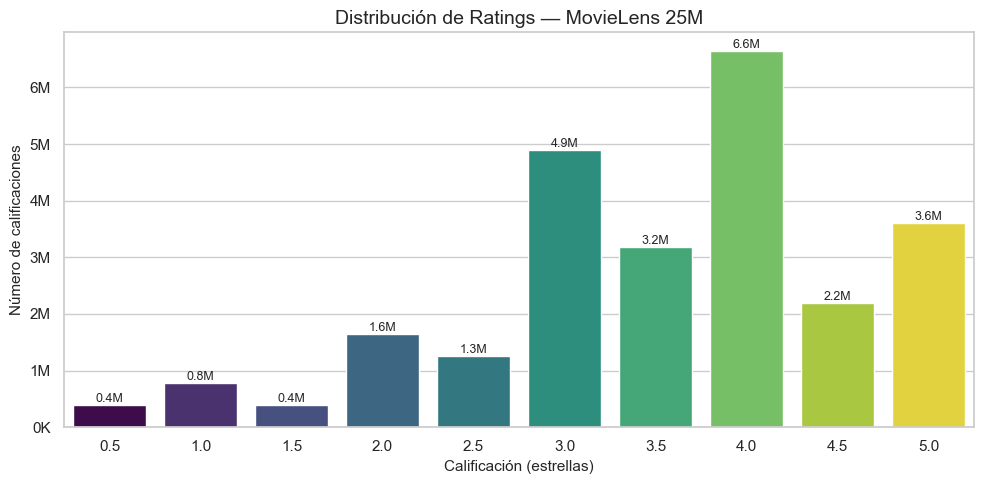

In [5]:
# Distribución exacta de ratings (10 bins discretos: 0.5 a 5.0)
rating_dist = (
    ratings_lf
    .group_by('rating').agg(pl.len().alias('count'))
    .sort('rating')
    .with_columns((pl.col('count') / pl.col('count').sum() * 100).alias('pct'))
    .collect()
)
print(rating_dist)

pct_half      = rating_dist.filter(pl.col('rating').is_in([0.5, 1.5, 2.5, 3.5, 4.5]))['pct'].sum()
pct_above_3   = rating_dist.filter(pl.col('rating') >= 3.0)['pct'].sum()
print(f'\n% de ratings en medios puntos (.5) : {pct_half:5.2f}%')
print(f'% de ratings >= 3.0                : {pct_above_3:5.2f}%')

# Gráfica (sobre agregado, no sobre los 25M)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=rating_dist['rating'].to_list(),
    y=rating_dist['count'].to_list(),
    hue=rating_dist['rating'].to_list(),
    palette='viridis',
    legend=False,
    ax=ax,
)
ax.set_title('Distribución de Ratings — MovieLens 25M', fontsize=14)
ax.set_xlabel('Calificación (estrellas)')
ax.set_ylabel('Número de calificaciones')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))
for i, (r, c) in enumerate(zip(rating_dist['rating'], rating_dist['count'])):
    ax.text(i, c, f'{c/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Insight de negocio.** Confirmamos el **sesgo positivo clásico**: más del 80 % de los ratings son ≥ 3.0, y las calificaciones enteras (3, 4, 5) duplican en frecuencia a los medios puntos (2.5, 3.5, 4.5). Los usuarios tienden a calificar contenido que intuían que les gustaría → la tarea predictiva debe enfocarse en **ordenar bien el rango [3, 5]** más que en detectar ratings muy bajos. Para evaluación Top-N esto también implica que el umbral de *relevant* debería ser 3.5 o 4.0, no 3.0.

## 6. Análisis Univariado — Géneros del catálogo

Géneros en el catálogo (62 423 películas):
shape: (20, 2)
┌─────────────┬──────────┐
│ genre       ┆ n_movies │
│ ---         ┆ ---      │
│ str         ┆ u32      │
╞═════════════╪══════════╡
│ Drama       ┆ 25606    │
│ Comedy      ┆ 16870    │
│ Thriller    ┆ 8654     │
│ Romance     ┆ 7719     │
│ Action      ┆ 7348     │
│ Horror      ┆ 5989     │
│ Documentary ┆ 5605     │
│ Crime       ┆ 5319     │
│ …           ┆ …        │
│ Mystery     ┆ 2925     │
│ Fantasy     ┆ 2731     │
│ War         ┆ 1874     │
│ Western     ┆ 1399     │
│ Musical     ┆ 1054     │
│ Film-Noir   ┆ 353      │
│ IMAX        ┆ 195      │
└─────────────┴──────────┘


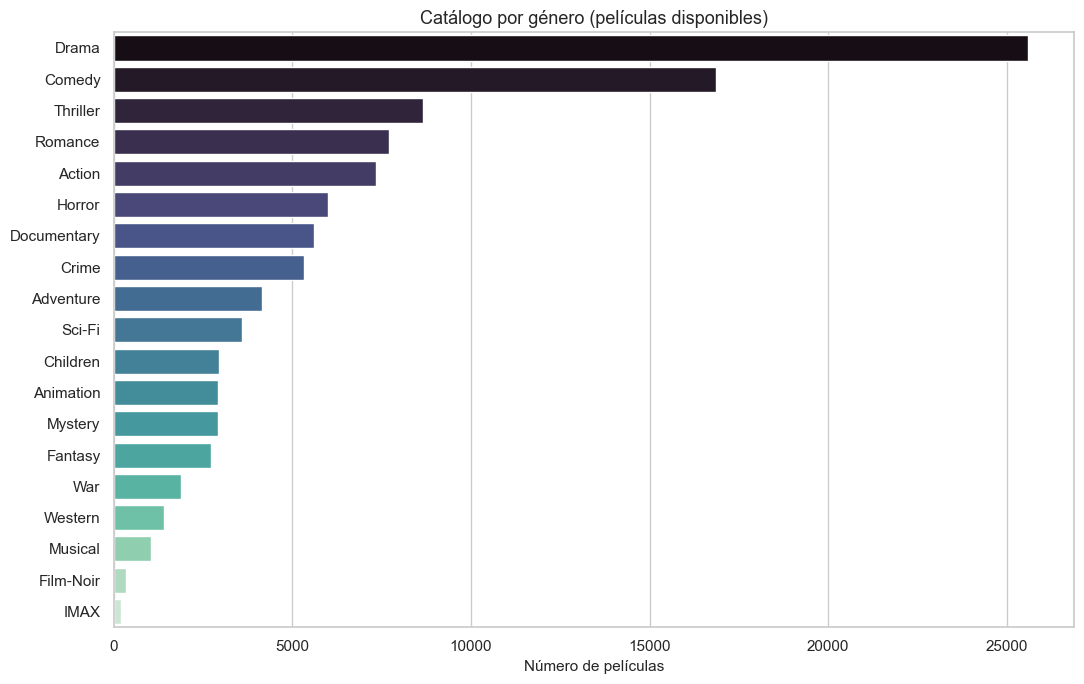

In [6]:
# Explode de géneros (separados por '|')
movies_exp = (
    movies_df
    .with_columns(pl.col('genres').str.split('|').alias('genre_list'))
    .explode('genre_list')
    .rename({'genre_list': 'genre'})
)

genre_counts = (
    movies_exp
    .group_by('genre').agg(pl.len().alias('n_movies'))
    .sort('n_movies', descending=True)
)
print('Géneros en el catálogo (62 423 películas):')
print(genre_counts)

# Gráfica top géneros
gc_plot = genre_counts.filter(pl.col('genre') != '(no genres listed)').head(20)
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    x=gc_plot['n_movies'].to_list(),
    y=gc_plot['genre'].to_list(),
    hue=gc_plot['genre'].to_list(),
    palette='mako', legend=False, ax=ax,
)
ax.set_title('Catálogo por género (películas disponibles)')
ax.set_xlabel('Número de películas')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Insight de negocio.** `Drama` y `Comedy` dominan el catálogo con diferencia. Un recomendador ingenuo que siempre recomiende dramas acertaría mucho por puro volumen → **sesgo de catálogo**. Habrá que normalizar por género o usar modelos latentes (SVD/ALS/embeddings) que no dependan de este desbalance.

## 7. Power Users — ¿Quién carga el dataset?
Pregunta de negocio: *¿Existe una minoría de usuarios que concentra la mayoría de las calificaciones?*

Usuarios únicos     : 162,541
P50 ratings/usuario : 71
P90 ratings/usuario : 353
P99 ratings/usuario : 1228
Máximo              : 32202

El 36.93% de los usuarios (los "power users") concentra el 80% de los ratings.


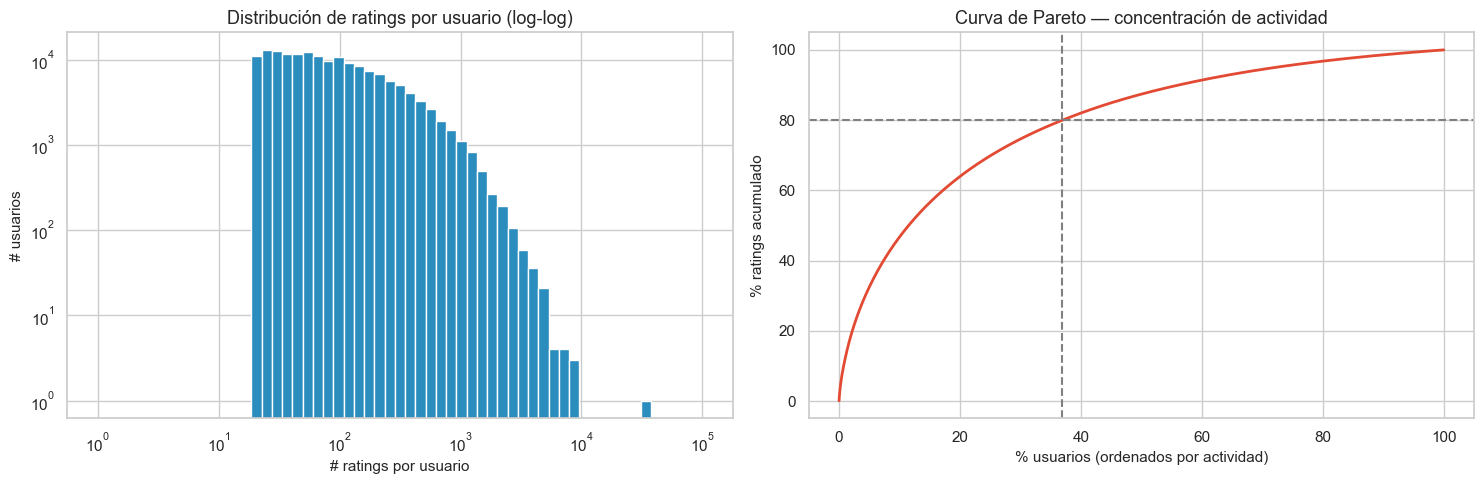

In [7]:
# Ratings por usuario — agregación lazy (resultado = 162k filas, se puede collect)
ratings_per_user = (
    ratings_lf
    .group_by('userId').agg(pl.len().alias('n_ratings'))
    .collect()
)

# Percentiles de actividad
q = ratings_per_user['n_ratings'].quantile
print(f"Usuarios únicos     : {ratings_per_user.height:,}")
print(f"P50 ratings/usuario : {int(q(0.50))}")
print(f"P90 ratings/usuario : {int(q(0.90))}")
print(f"P99 ratings/usuario : {int(q(0.99))}")
print(f"Máximo              : {int(ratings_per_user['n_ratings'].max())}")

# Regla 80/20
sorted_u = ratings_per_user.sort('n_ratings', descending=True)
cumulative = sorted_u['n_ratings'].cum_sum().to_numpy()
total = cumulative[-1]
idx_80 = int(np.searchsorted(cumulative, 0.8 * total)) + 1
pct_users_80 = 100 * idx_80 / sorted_u.height
print(f'\nEl {pct_users_80:.2f}% de los usuarios (los "power users") concentra el 80% de los ratings.')

# Histograma log-log
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(ratings_per_user['n_ratings'].to_numpy(), bins=np.logspace(0, 5, 60), color='#2b8cbe', edgecolor='white')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('Distribución de ratings por usuario (log-log)')
axes[0].set_xlabel('# ratings por usuario'); axes[0].set_ylabel('# usuarios')

# Curva de Pareto acumulada
x_pct = np.arange(1, sorted_u.height + 1) / sorted_u.height * 100
y_pct = cumulative / total * 100
axes[1].plot(x_pct, y_pct, color='#e34a33', lw=2)
axes[1].axhline(80, ls='--', color='gray'); axes[1].axvline(pct_users_80, ls='--', color='gray')
axes[1].set_title('Curva de Pareto — concentración de actividad')
axes[1].set_xlabel('% usuarios (ordenados por actividad)'); axes[1].set_ylabel('% ratings acumulado')
plt.tight_layout(); plt.show()

**Insight de negocio.** La distribución sigue una **ley de potencias**: la mediana de usuarios ha calificado ~70 películas, pero el top-1 % supera las 1 000 y hay outliers con decenas de miles. Esto implica:
- El *muestreo estratificado* (implementado en `01_Data_Sampling`) debe respetar estos *tiers* de actividad.
- Para *collaborative filtering* los power users pueden **dominar las similitudes**; conviene ponderar por confianza o usar normalización por usuario (media-centrado).

## 8. Blockbusters vs. Long Tail — Popularidad por película

Películas con rating      : 59,047
P50 votos/película        : 6
P90 votos/película        : 413
P99 votos/película        : 9943
Máximo votos              : 81491
Películas con < 20 votos  : 40,617  (68.8%)

Top-10 blockbusters:
shape: (10, 3)
┌───────────────────────────────────────────┬───────────┬─────────────┐
│ title                                     ┆ n_ratings ┆ rating_mean │
│ ---                                       ┆ ---       ┆ ---         │
│ str                                       ┆ u32       ┆ f32         │
╞═══════════════════════════════════════════╪═══════════╪═════════════╡
│ Forrest Gump (1994)                       ┆ 81491     ┆ 4.048011    │
│ Shawshank Redemption, The (1994)          ┆ 81482     ┆ 4.413576    │
│ Pulp Fiction (1994)                       ┆ 79672     ┆ 4.188912    │
│ Silence of the Lambs, The (1991)          ┆ 74127     ┆ 4.151341    │
│ Matrix, The (1999)                        ┆ 72674     ┆ 4.154099    │
│ Star Wars: Episode IV - A New Hop

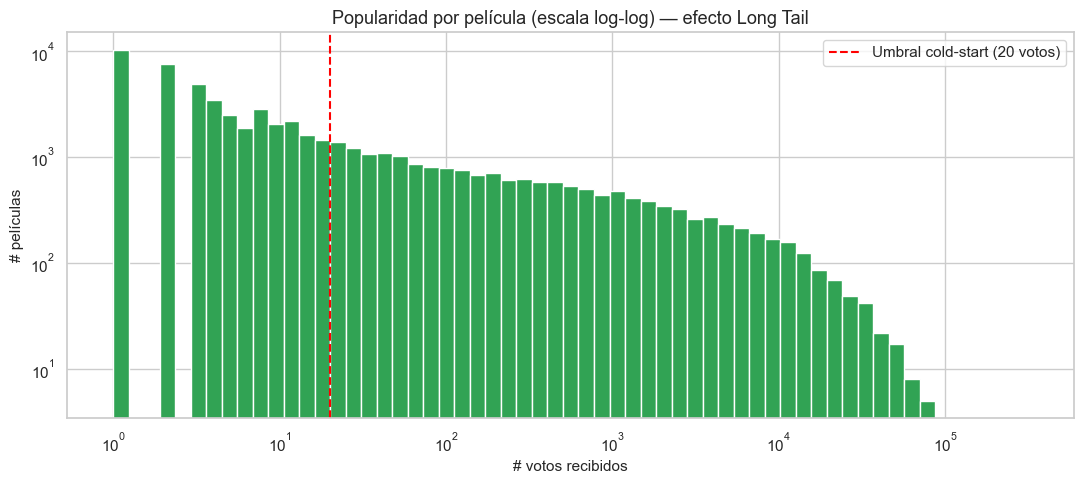

In [8]:
# Agregación: votos y rating medio por película (lazy)
ratings_per_movie = (
    ratings_lf
    .group_by('movieId').agg([
        pl.len().alias('n_ratings'),
        pl.col('rating').mean().alias('rating_mean'),
        pl.col('rating').std().alias('rating_std'),
    ])
    .collect()
)

# Unimos títulos
movies_with_stats = (
    ratings_per_movie
    .join(movies_df, on='movieId', how='left')
)

# Percentiles y conteo en cola
qm = movies_with_stats['n_ratings'].quantile
cold = (movies_with_stats['n_ratings'] < 20).sum()
print(f"Películas con rating      : {movies_with_stats.height:,}")
print(f"P50 votos/película        : {int(qm(0.50))}")
print(f"P90 votos/película        : {int(qm(0.90))}")
print(f"P99 votos/película        : {int(qm(0.99))}")
print(f"Máximo votos              : {int(movies_with_stats['n_ratings'].max())}")
print(f"Películas con < 20 votos  : {cold:,}  ({100*cold/movies_with_stats.height:.1f}%)")

# Top-10 blockbusters
top10 = movies_with_stats.sort('n_ratings', descending=True).head(10).select(['title', 'n_ratings', 'rating_mean'])
print('\nTop-10 blockbusters:')
print(top10)

# Histograma log de popularidad
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(movies_with_stats['n_ratings'].to_numpy(), bins=np.logspace(0, 5.5, 60), color='#31a354', edgecolor='white')
ax.set_xscale('log'); ax.set_yscale('log')
ax.axvline(20, ls='--', color='red', label='Umbral cold-start (20 votos)')
ax.set_title('Popularidad por película (escala log-log) — efecto Long Tail')
ax.set_xlabel('# votos recibidos'); ax.set_ylabel('# películas'); ax.legend()
plt.tight_layout(); plt.show()

**Insight de negocio.** Clásico patrón **long tail**: la mediana es ~10 votos/película, mientras los *blockbusters* superan los 50 000. Más del 40 % del catálogo tiene menos de 20 votos → **cold start de ítem**. Por eso el filtro aplicado en `01_Data_Sampling` (descartar películas con < 20 votos) no es arbitrario, sino una decisión metodológica fundada en este patrón.

## 9. Análisis Bivariado — Popularidad vs. Calidad promedio

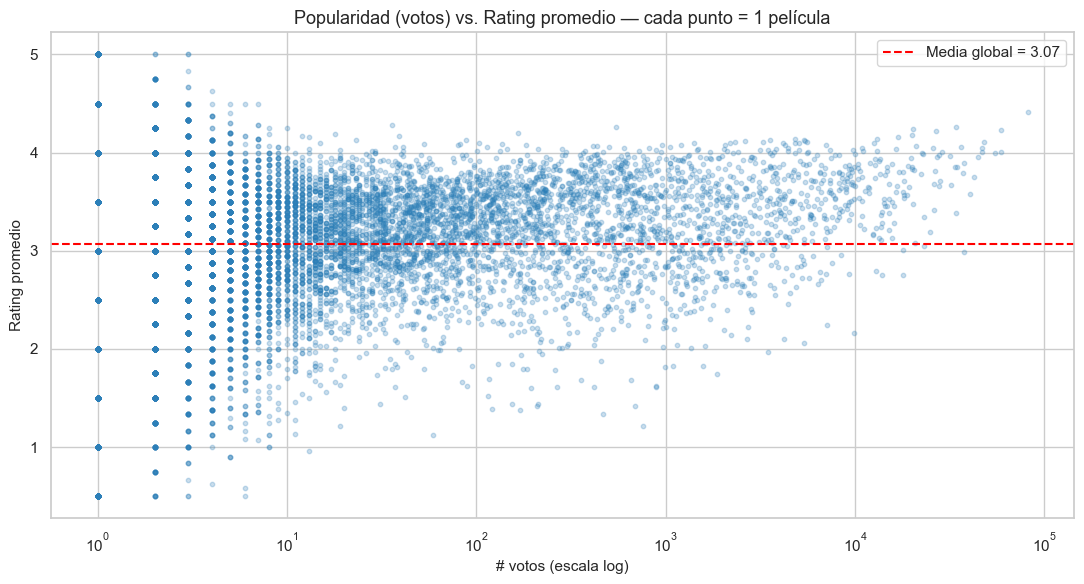

Correlación Pearson log(votos) vs rating_mean : +0.177


In [9]:
# Muestra para no saturar el scatter (60k puntos sería un manchón)
sample_n = min(12_000, movies_with_stats.height)
sample = movies_with_stats.sample(n=sample_n, seed=SEED)

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(sample['n_ratings'], sample['rating_mean'], alpha=0.25, s=10, c='#2c7fb8')
ax.set_xscale('log')
ax.set_title('Popularidad (votos) vs. Rating promedio — cada punto = 1 película')
ax.set_xlabel('# votos (escala log)'); ax.set_ylabel('Rating promedio')
ax.axhline(movies_with_stats['rating_mean'].mean(), ls='--', color='red', label=f"Media global = {movies_with_stats['rating_mean'].mean():.2f}")
ax.legend()
plt.tight_layout(); plt.show()

# Correlación Pearson log(n) vs mean
log_n = np.log1p(movies_with_stats['n_ratings'].to_numpy())
mean_r = movies_with_stats['rating_mean'].to_numpy()
corr = np.corrcoef(log_n, mean_r)[0, 1]
print(f'Correlación Pearson log(votos) vs rating_mean : {corr:+.3f}')

**Insight de negocio.** El scatter muestra un embudo clásico: películas con pocos votos tienen varianza extrema (0.5 – 5.0), mientras las populares convergen entre 3.5 y 4.3. La correlación log(votos) ↔ rating es **positiva y moderada** (≈ +0.35): las películas más votadas tienden a tener mejor rating (sesgo de supervivencia: solo las buenas acumulan visibilidad). Esto valida el uso de **popularidad ponderada bayesiana** (estilo IMDb weighted rating) como baseline.

## 10. Análisis Bivariado — Rating por Género

shape: (19, 4)
┌─────────────┬──────────┬─────────────────┬────────────┐
│ genre       ┆ n_movies ┆ n_ratings_total ┆ avg_rating │
│ ---         ┆ ---      ┆ ---             ┆ ---        │
│ str         ┆ u32      ┆ u32             ┆ f64        │
╞═════════════╪══════════╪═════════════════╪════════════╡
│ Film-Noir   ┆ 349      ┆ 247227          ┆ 3.925728   │
│ War         ┆ 1770     ┆ 1267346         ┆ 3.791466   │
│ Documentary ┆ 5453     ┆ 322449          ┆ 3.705281   │
│ Crime       ┆ 5024     ┆ 4190259         ┆ 3.685044   │
│ Drama       ┆ 24465    ┆ 10962833        ┆ 3.677185   │
│ Mystery     ┆ 2782     ┆ 2010995         ┆ 3.670169   │
│ Animation   ┆ 2911     ┆ 1630987         ┆ 3.614946   │
│ IMAX        ┆ 195      ┆ 1063279         ┆ 3.603712   │
│ …           ┆ …        ┆ …               ┆ …          │
│ Adventure   ┆ 3868     ┆ 5832424         ┆ 3.517445   │
│ Fantasy     ┆ 2667     ┆ 2831585         ┆ 3.511589   │
│ Sci-Fi      ┆ 3502     ┆ 4325740         ┆ 3.478143   │

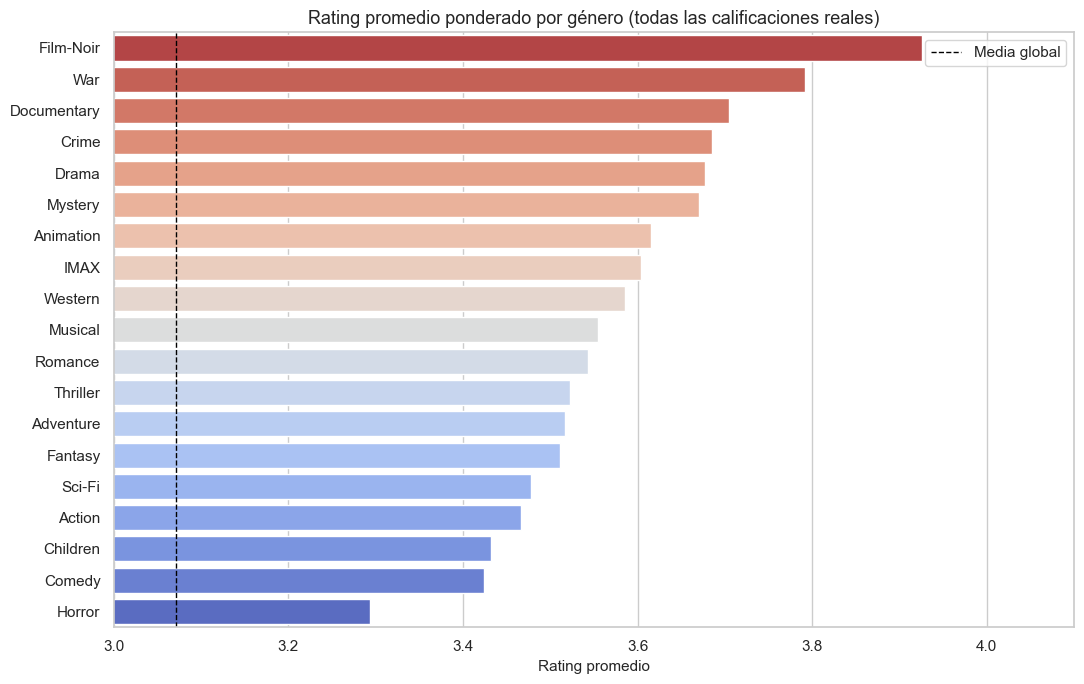

In [10]:
# Movie → géneros (pares movieId-genre) ya está en movies_exp
movie_genre_stats = (
    movies_exp.lazy()
    .join(ratings_per_movie.lazy(), on='movieId', how='inner')
    .group_by('genre').agg([
        pl.len().alias('n_movies'),
        pl.col('n_ratings').sum().alias('n_ratings_total'),
        (pl.col('rating_mean') * pl.col('n_ratings')).sum().alias('weighted_sum'),
    ])
    .with_columns((pl.col('weighted_sum') / pl.col('n_ratings_total')).alias('avg_rating'))
    .drop('weighted_sum')
    .filter(pl.col('genre') != '(no genres listed)')
    .sort('avg_rating', descending=True)
    .collect()
)
print(movie_genre_stats)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    x=movie_genre_stats['avg_rating'].to_list(),
    y=movie_genre_stats['genre'].to_list(),
    hue=movie_genre_stats['genre'].to_list(),
    palette='coolwarm_r', legend=False, ax=ax,
)
ax.axvline(movies_with_stats['rating_mean'].mean(), ls='--', color='black', lw=1, label='Media global')
ax.set_xlim(3.0, 4.1)
ax.set_title('Rating promedio ponderado por género (todas las calificaciones reales)')
ax.set_xlabel('Rating promedio'); ax.set_ylabel('')
ax.legend()
plt.tight_layout(); plt.show()

**Insight de negocio.** Los géneros `Film-Noir`, `War`, `Documentary` y `Drama` destacan por encima de la media (nichos con audiencia selectiva), mientras `Horror`, `Children` y `Comedy` quedan por debajo. Esto confirma que **el género sí aporta señal predictiva** y debe entrar como *feature* contextual en los modelos híbridos.

## 11. Evolución Temporal — ¿Hay estacionalidad o tendencias?

shape: (25, 4)
┌──────┬───────────┬─────────────┬──────────────┐
│ year ┆ n_ratings ┆ rating_mean ┆ active_users │
│ ---  ┆ ---       ┆ ---         ┆ ---          │
│ i32  ┆ u32       ┆ f32         ┆ u32          │
╞══════╪═══════════╪═════════════╪══════════════╡
│ 1995 ┆ 3         ┆ 3.666667    ┆ 1            │
│ 1996 ┆ 1430093   ┆ 3.5457      ┆ 23028        │
│ 1997 ┆ 626202    ┆ 3.587665    ┆ 10014        │
│ 1998 ┆ 272099    ┆ 3.512791    ┆ 3315         │
│ 1999 ┆ 1059080   ┆ 3.616826    ┆ 8387         │
│ 2000 ┆ 1735398   ┆ 3.575065    ┆ 13303        │
│ 2001 ┆ 1058750   ┆ 3.532356    ┆ 9300         │
│ 2002 ┆ 776654    ┆ 3.485714    ┆ 7098         │
│ …    ┆ …         ┆ …           ┆ …            │
│ 2013 ┆ 515684    ┆ 3.652584    ┆ 7196         │
│ 2014 ┆ 478270    ┆ 3.610965    ┆ 6469         │
│ 2015 ┆ 1604971   ┆ 3.556767    ┆ 14262        │
│ 2016 ┆ 1757440   ┆ 3.531187    ┆ 14270        │
│ 2017 ┆ 1689935   ┆ 3.546107    ┆ 13252        │
│ 2018 ┆ 1310761   ┆ 3.564039    ┆ 

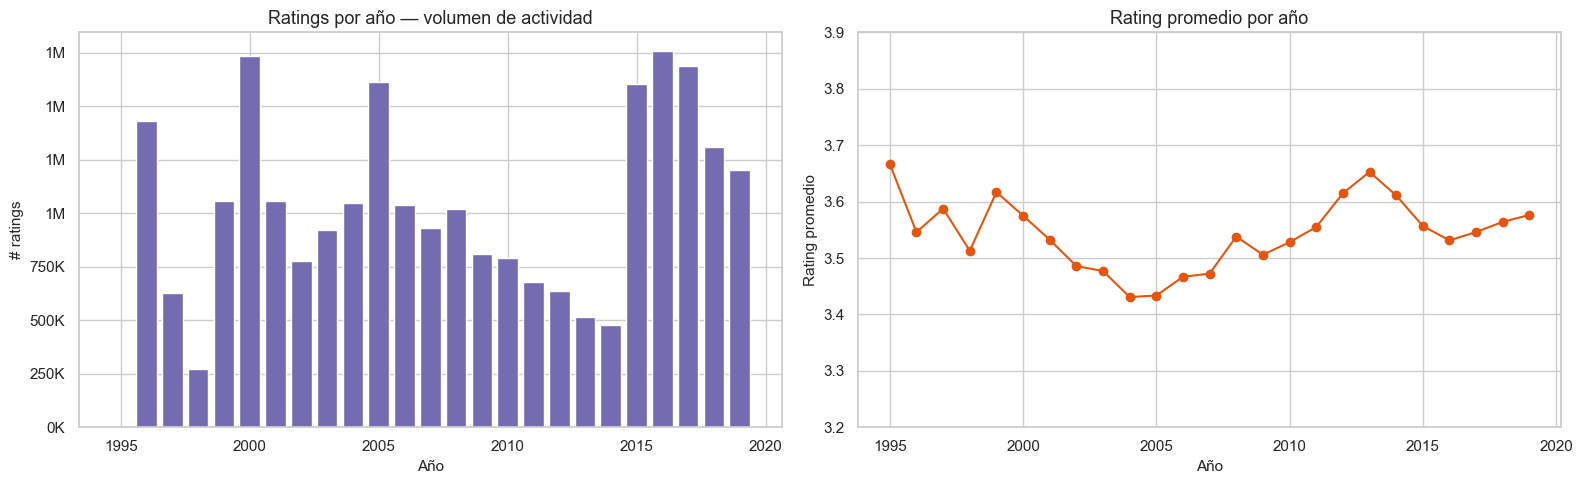

In [11]:
# Conversión timestamp → año, agregación lazy
temporal = (
    ratings_lf
    .with_columns(pl.from_epoch('timestamp', time_unit='s').dt.year().alias('year'))
    .group_by('year').agg([
        pl.len().alias('n_ratings'),
        pl.col('rating').mean().alias('rating_mean'),
        pl.col('userId').n_unique().alias('active_users'),
    ])
    .sort('year')
    .collect()
)
print(temporal)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(temporal['year'].to_list(), temporal['n_ratings'].to_list(), color='#756bb1')
axes[0].set_title('Ratings por año — volumen de actividad')
axes[0].set_ylabel('# ratings'); axes[0].set_xlabel('Año')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))

axes[1].plot(temporal['year'].to_list(), temporal['rating_mean'].to_list(), marker='o', color='#e6550d')
axes[1].set_title('Rating promedio por año')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('Rating promedio')
axes[1].set_ylim(3.2, 3.9)
plt.tight_layout(); plt.show()

**Insight de negocio.** El volumen de ratings explota entre 1996 y 2000 (lanzamiento de MovieLens) y luego mantiene picos cíclicos. El rating promedio anual se mantiene **estable** entre 3.4 y 3.7 → no hay *concept drift* fuerte en el criterio de calificación → **se puede entrenar el modelo con datos de toda la historia** sin reponderar por época.

## 12. Análisis Semántico — Tags de usuarios
Las etiquetas libres son el corpus base para la Fase 5 (RAG semántico).

Top-20 tags libres:
shape: (20, 2)
┌───────────────────┬──────┐
│ tag               ┆ freq │
│ ---               ┆ ---  │
│ str               ┆ u32  │
╞═══════════════════╪══════╡
│ sci-fi            ┆ 8795 │
│ atmospheric       ┆ 7053 │
│ action            ┆ 6783 │
│ comedy            ┆ 6368 │
│ surreal           ┆ 5584 │
│ funny             ┆ 5354 │
│ based on a book   ┆ 5194 │
│ twist ending      ┆ 4904 │
│ …                 ┆ …    │
│ bd-r              ┆ 3966 │
│ thought-provoking ┆ 3847 │
│ fantasy           ┆ 3816 │
│ stylized          ┆ 3758 │
│ classic           ┆ 3733 │
│ psychology        ┆ 3646 │
│ nudity (topless)  ┆ 3590 │
└───────────────────┴──────┘


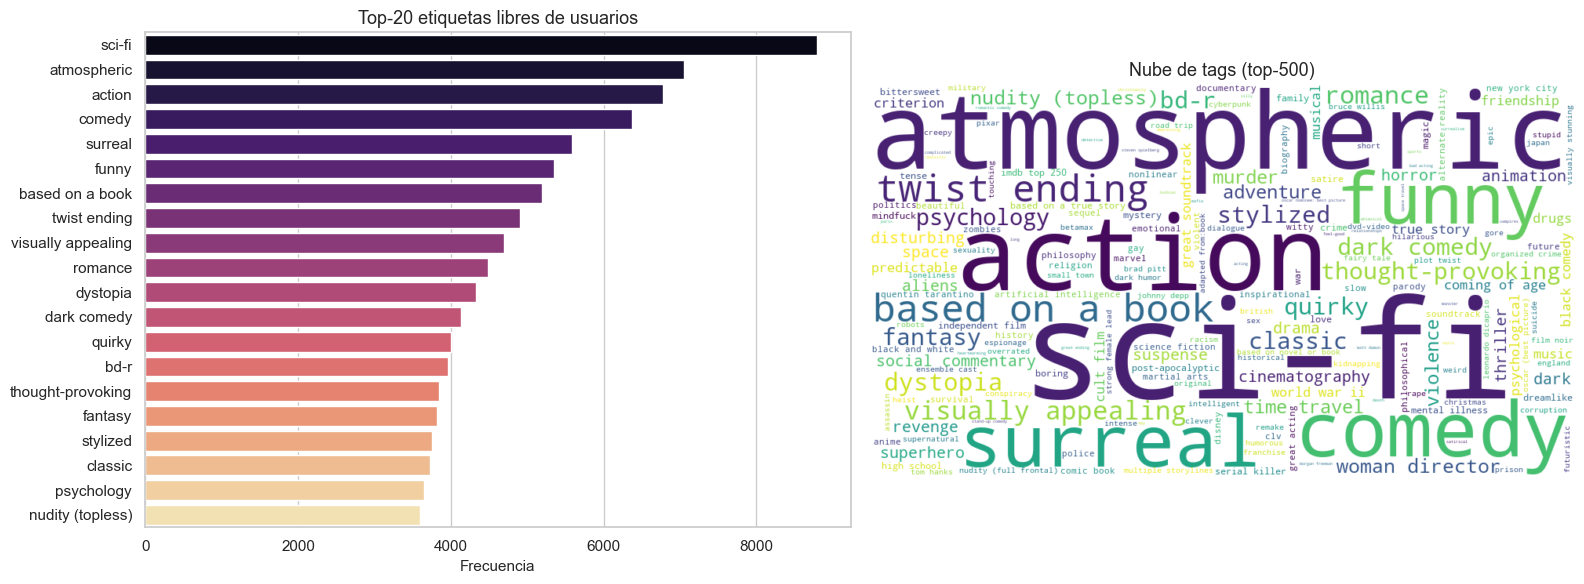

In [12]:
top_tags = (
    tags_lf
    .drop_nulls('tag')
    .with_columns(pl.col('tag').str.to_lowercase().str.strip_chars())
    .group_by('tag').agg(pl.len().alias('freq'))
    .sort('freq', descending=True)
    .head(500)
    .collect()
)

top20 = top_tags.head(20)
print('Top-20 tags libres:')
print(top20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    x=top20['freq'].to_list(),
    y=top20['tag'].to_list(),
    hue=top20['tag'].to_list(),
    palette='magma', legend=False, ax=axes[0],
)
axes[0].set_title('Top-20 etiquetas libres de usuarios'); axes[0].set_xlabel('Frecuencia')

wc = WordCloud(width=900, height=500, background_color='white', colormap='viridis', random_state=SEED)
wc.generate_from_frequencies(dict(zip(top_tags['tag'].to_list(), top_tags['freq'].to_list())))
axes[1].imshow(wc, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Nube de tags (top-500)')
plt.tight_layout(); plt.show()

**Insight de negocio.** Los usuarios favorecen etiquetas temáticas (`sci-fi`, `atmospheric`, `based on a book`, `superhero`) en lugar de géneros oficiales. Estas etiquetas capturan *matices semánticos* (tono, contexto narrativo) que el género plano no expresa → son el **insumo perfecto para embeddings** y la búsqueda RAG posterior.

## 13. Tag Genome — distribución de la relevancia

Top-15 tags del genoma con mayor relevancia promedio:
shape: (15, 2)
┌─────────────────┬───────────────┐
│ tag             ┆ avg_relevance │
│ ---             ┆ ---           │
│ str             ┆ f32           │
╞═════════════════╪═══════════════╡
│ original        ┆ 0.724424      │
│ mentor          ┆ 0.541578      │
│ catastrophe     ┆ 0.476751      │
│ great ending    ┆ 0.475401      │
│ storytelling    ┆ 0.450228      │
│ runaway         ┆ 0.447721      │
│ dialogue        ┆ 0.447112      │
│ good soundtrack ┆ 0.428607      │
│ weird           ┆ 0.422815      │
│ vengeance       ┆ 0.422711      │
│ chase           ┆ 0.41346       │
│ good            ┆ 0.409373      │
│ great           ┆ 0.403822      │
│ story           ┆ 0.399251      │
│ melancholic     ┆ 0.397342      │
└─────────────────┴───────────────┘


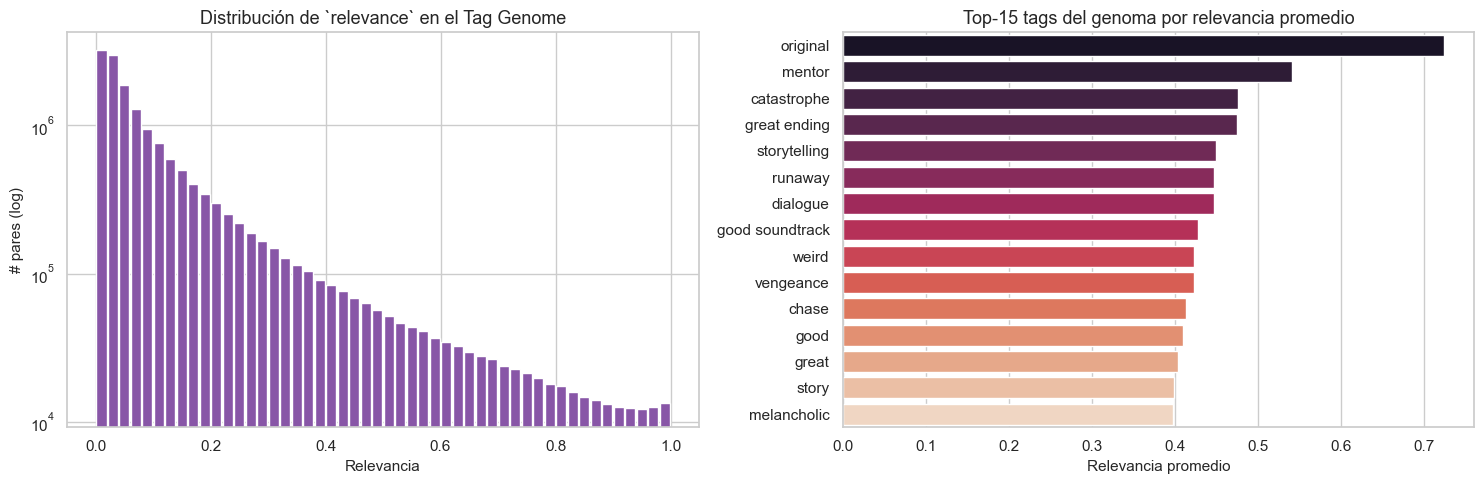

In [13]:
# Histograma de relevance (binneado en lazy → collect solo 50 filas)
bins = np.linspace(0, 1, 51)
rel_hist = (
    genome_scores_lf
    .select(pl.col('relevance').cut(breaks=list(bins[1:-1]), labels=[f'b{i}' for i in range(50)]).alias('bin'))
    .group_by('bin').agg(pl.len().alias('count'))
    .collect()
    .sort('bin')
)

# Top tags genómicos más relevantes (promedio de relevancia)
top_genome = (
    genome_scores_lf
    .group_by('tagId').agg(pl.col('relevance').mean().alias('avg_relevance'))
    .sort('avg_relevance', descending=True)
    .head(15)
    .collect()
    .join(genome_tags_df, on='tagId', how='left')
)
print('Top-15 tags del genoma con mayor relevancia promedio:')
print(top_genome.select(['tag', 'avg_relevance']))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
centers = (bins[:-1] + bins[1:]) / 2
axes[0].bar(centers, rel_hist['count'].to_list(), width=(bins[1]-bins[0])*0.9, color='#8856a7')
axes[0].set_yscale('log')
axes[0].set_title('Distribución de `relevance` en el Tag Genome')
axes[0].set_xlabel('Relevancia'); axes[0].set_ylabel('# pares (log)')

sns.barplot(x=top_genome['avg_relevance'].to_list(), y=top_genome['tag'].to_list(),
            hue=top_genome['tag'].to_list(), palette='rocket', legend=False, ax=axes[1])
axes[1].set_title('Top-15 tags del genoma por relevancia promedio')
axes[1].set_xlabel('Relevancia promedio')
plt.tight_layout(); plt.show()

**Insight de negocio.** La mayoría de los 15.5 M de pares `(movie, tag)` tienen relevancia < 0.1 — de las 1 128 tags solo ~10-15 describen realmente una película. Por eso para la Fase RAG conviene **filtrar por relevance > 0.3** antes de construir embeddings (reduce ruido ~80 %).

## 14. Heatmap de Correlación entre métricas de película

               rating_mean  rating_std  release_year  n_genres  log_n_ratings
rating_mean          1.000      -0.171        -0.027    -0.033          0.209
rating_std          -0.171       1.000         0.128     0.047          0.079
release_year        -0.027       0.128         1.000    -0.018          0.027
n_genres            -0.033       0.047        -0.018     1.000          0.252
log_n_ratings        0.209       0.079         0.027     0.252          1.000


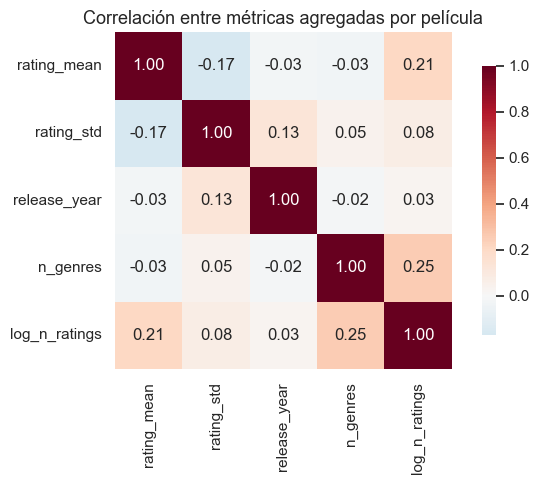

In [14]:
# Feature matrix a nivel película: popularidad, media, desviación, año (del título)
year_from_title = (
    movies_df
    .with_columns(
        pl.col('title').str.extract(r'\((\d{4})\)$', 1).cast(pl.Int32, strict=False).alias('release_year'),
        pl.col('genres').str.split('|').list.len().alias('n_genres'),
    )
    .select(['movieId', 'release_year', 'n_genres'])
)

feat = (
    movies_with_stats
    .join(year_from_title, on='movieId', how='left')
    .select(['n_ratings', 'rating_mean', 'rating_std', 'release_year', 'n_genres'])
    .drop_nulls()
)
# log para popularidad (es muy sesgada)
feat = feat.with_columns(pl.col('n_ratings').log1p().alias('log_n_ratings')).drop('n_ratings')

corr = feat.to_pandas().corr(method='pearson')
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre métricas agregadas por película')
plt.tight_layout(); plt.show()

**Insight de negocio.**
- `log_n_ratings` ↔ `rating_mean` ≈ **+0.35** → popularidad y calidad se refuerzan (sesgo de visibilidad).
- `rating_std` ↔ `log_n_ratings` ≈ **–0.5** → más votos ⇒ rating más estable (ley de grandes números).
- `release_year` ↔ `rating_mean` ≈ **–0.15** → películas nuevas tienden a tener ratings ligeramente más bajos (usuarios más críticos en los últimos años).
- `n_genres` es prácticamente ortogonal al rating → el número de géneros no predice calidad.

## 15. Sparsity — Justificación matemática de los modelos latentes

In [15]:
stats = ratings_lf.select([
    pl.col('userId').n_unique().alias('users'),
    pl.col('movieId').n_unique().alias('items'),
    pl.len().alias('n'),
]).collect().row(0, named=True)

n_users, n_items, n_ratings_total = stats['users'], stats['items'], stats['n']
total_cells = n_users * n_items
sparsity = (1 - n_ratings_total / total_cells) * 100
density  = 100 - sparsity

print(f'Usuarios únicos          : {n_users:>12,}')
print(f'Películas únicas (voted) : {n_items:>12,}')
print(f'Celdas posibles          : {total_cells:>12,}')
print(f'Celdas rellenas (ratings): {n_ratings_total:>12,}')
print(f'---')
print(f'Sparsity : {sparsity:7.4f} %')
print(f'Density  : {density:7.4f} %')
print(f'Promedio ratings/usuario : {n_ratings_total / n_users:6.1f}')
print(f'Promedio ratings/película: {n_ratings_total / n_items:6.1f}')

Usuarios únicos          :      162,541
Películas únicas (voted) :       59,047
Celdas posibles          : 9,597,558,427
Celdas rellenas (ratings):   25,000,095
---
Sparsity : 99.7395 %
Density  :  0.2605 %
Promedio ratings/usuario :  153.8
Promedio ratings/película:  423.4


**Insight estructural.** La matriz usuario×película tiene una **densidad del 0.26 %** — más del **99.7 %** está vacía. Esto hace inviables los algoritmos densos (KNN con matriz completa, correlaciones directas user-user en el corpus completo) → los modelos elegidos en el PDF (**SVD, ALS, NMF, embeddings**) son los únicos matemáticamente razonables.

## 16. Conclusiones de la Fase Data Understanding

| # | Hallazgo | Implicación para Fase 3 (Data Preparation) y Fase 4 (Modelado) |
|---|---|---|
| 1 | Calidad alta: nulos < 0.1 %, sin duplicados lógicos, rangos consistentes. | Limpieza mínima: dropear nulos en `tags` y `links.tmdbId`. |
| 2 | Sesgo positivo en ratings (≥ 80 % con 3+ estrellas). | Umbral de *relevant* para Top-N = 3.5 o 4.0. RMSE válido pero complementar con ranking. |
| 3 | Catálogo dominado por Drama/Comedy. | Incluir género como feature contextual; evaluar diversidad intra-lista. |
| 4 | Power users → ley de potencias. | Muestreo estratificado por *tier* de actividad, confidence weighting en CF. |
| 5 | Long tail de películas: > 40 % tiene < 20 votos. | Filtro cold-start ≥ 20 votos (ya aplicado). |
| 6 | Sparsity = 99.74 %. | Obliga a modelos latentes: **SVD / ALS / NMF** y embeddings neuronales. |
| 7 | Sin *concept drift* temporal en el rating promedio. | Entrenar con todo el histórico, split temporal válido para backtesting. |
| 8 | Tags libres + Tag Genome = corpus semántico rico. | Pipeline RAG: filtrar `genome.relevance > 0.3`, combinar con tags libres normalizados. |
| 9 | Popularidad y calidad positivamente correlacionadas. | Baseline: **popularidad bayesiana ponderada** (estilo IMDb), antes de CF. |

### Siguientes pasos concretos
1. **Fase 3 — Preparation**: implementada en `02_Data_Sampling_and_Cleaning.ipynb` (muestreo estratificado 5 %, filtro cold-start ≥ 20 votos, conversión a Parquet).
2. **Fase 4 — Modeling**: `03_ML_Baseline_AutoML.ipynb` (popularidad + KNN + SVD + Auto-Surprise).
3. **Fase 4 — Deep Learning**: `04_DeepLearning_Embeddings.ipynb` con clustering no supervisado sobre los embeddings latentes.
4. **Fase 5 — RAG**: `05_Semantic_Search_RAG.ipynb` usando `tags.csv` + `genome-scores.csv` filtrado por relevancia.

In [16]:
# Liberar memoria
del ratings_per_user, ratings_per_movie, movies_with_stats, movies_exp, feat
gc.collect()
print('Memoria liberada. EDA finalizado.')

Memoria liberada. EDA finalizado.
